In [56]:
import sys
!{sys.executable} -m pip install torch torchvision

In [58]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler

import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

In [59]:
# Define the transforms
# Train with augmentation
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # ensure grayscale
    transforms.Resize((48, 48)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [60]:
# Define the transforms 
# Test / Validation
test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [61]:
# Loading the dataset
train_dataset_full = datasets.ImageFolder("/Users/krishajh/Desktop/undergrad/fourth_year/deep_learning/final_project/archive/train/", transform=train_transform)
test_dataset = datasets.ImageFolder("/Users/krishajh/Desktop/undergrad/fourth_year/deep_learning/final_project/archive/test/", transform=test_transform)

In [62]:
#print(train_dataset_full.classes)
idx_to_class = {v: k for k, v in train_dataset_full.class_to_idx.items()}
print(idx_to_class)

{0: 'angry', 1: 'disgust', 2: 'fear', 3: 'happy', 4: 'neutral', 5: 'sad', 6: 'surprise'}


In [63]:
# Create the Validation Split 
train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

train_dataset, val_dataset = random_split(train_dataset_full, [train_size, val_size])
print("Train size:", len(train_dataset))
print("Val size: ", len(val_dataset))

Train size: 22967
Val size:  5742


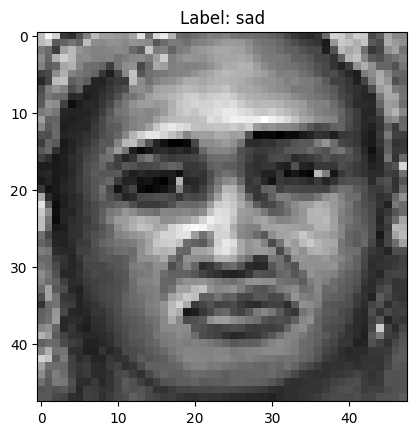

In [64]:
# Visualize one sample image as a sanity check 
image, label = train_dataset[0]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {idx_to_class[labels[0].item()]}")
plt.show()

In [65]:
# Check class imbalance 
labels = [label for _, label in train_dataset_full]
from collections import Counter

class_counts = Counter(labels)
print("Class counts:", class_counts)

Class counts: Counter({3: 7215, 4: 4965, 5: 4830, 2: 4097, 0: 3995, 6: 3171, 1: 436})


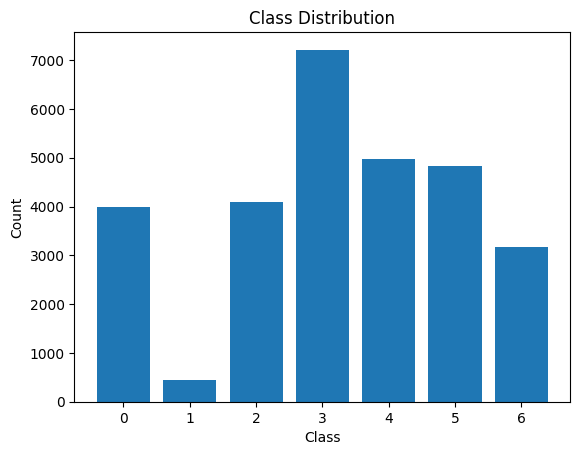

In [66]:
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [67]:
# Compute class weights 
total = sum(class_counts.values())
class_weights = [total / class_counts[i] for i in range(len(class_counts))]

class_weights = torch.tensor(class_weights, dtype=torch.float)
print("Class weights:", class_weights)

Class weights: tensor([ 7.1862, 65.8463,  7.0073,  3.9791,  5.7823,  5.9439,  9.0536])


In [68]:
# Weighted Sampler 
train_labels = [train_dataset_full.targets[i] for i in train_dataset.indices]
sample_weights = [class_weights[label] for label in train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement = True)

In [69]:
# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [70]:
# Final Check 
images, labels = next(iter(train_loader))

print("Image shape:", images.shape)
print("Labels shape:", labels.shape)

Image shape: torch.Size([64, 1, 48, 48])
Labels shape: torch.Size([64])


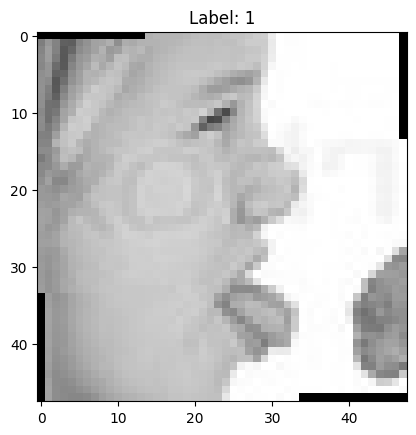

In [71]:
# Visualize Augmeneted Image 
plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(f"Label: {labels[0].item()}")
plt.show()